In [1]:
from langchain_groq import ChatGroq
from pprint import pprint
import os

if os.environ['GROQ_API_KEY']:
    print("GROQ_API_KEY is set.")
else:
    raise ValueError("GROQ_API_KEY is not set. Please set it in your .env file.")

d:\GEN-AI\.venv\Lib\site-packages\langchain_core\_api\deprecation.py:25: UserWarning: Core Pydantic V1 functionality isn't compatible with Python 3.14 or greater.
  from pydantic.v1.fields import FieldInfo as FieldInfoV1
d:\GEN-AI\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GROQ_API_KEY is set.


In [2]:
llm = ChatGroq(model='meta-llama/llama-4-scout-17b-16e-instruct', temperature=0.5)
llm

ChatGroq(profile={'max_input_tokens': 131072, 'max_output_tokens': 8192, 'image_inputs': True, 'audio_inputs': False, 'video_inputs': False, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': False, 'tool_calling': True}, client=<groq.resources.chat.completions.Completions object at 0x000002D3E66306E0>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000002D3E6631160>, model_name='meta-llama/llama-4-scout-17b-16e-instruct', temperature=0.5, model_kwargs={}, groq_api_key=SecretStr('**********'))

### **Pydantic Schema**

In [3]:
from pydantic import BaseModel, Field 

class graph_schema(BaseModel):

    topic: str = Field(description="The topic of the graph")
    post: str = Field(description="The LinkedIn post content")
    curated_post: str = Field(description="The curated LinkedIn post content")


demo_obj = graph_schema(
    topic="The importance of data privacy in the digital age",
    post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy.",
    curated_post="In the digital age, data privacy is more important than ever. With the"
)
print(demo_obj)

topic='The importance of data privacy in the digital age' post="Data privacy is crucial in today's digital world. With the increasing amount of personal information being shared online, it's important to understand how to protect your data and maintain your privacy." curated_post='In the digital age, data privacy is more important than ever. With the'


In [4]:
def create_post(state: graph_schema) -> graph_schema:
    
    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the topic from the state
    topic = state['topic']

    # Passing the topic to the LLM to generate a LinkedIn post
    post = llm.invoke(f"Write a LinkedIn post about {topic}").content

    # Update the state with the generated post
    state['post'] = post

    return state


def curate_post(state: graph_schema) -> graph_schema:

    # Convert the Pydantic model to a dictionary
    state = state.model_dump()

    # Extract the post from the state
    post = state['post']

    # Passing the post to the LLM to curate it
    curated_post = llm.invoke(f"Curate the following LinkedIn post with GenZ tone: {post}").content


    # Update the state with the curated post
    state['curated_post'] = curated_post

    return state

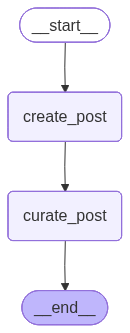

In [5]:
from langgraph.graph import StateGraph, START, END

graph = StateGraph(graph_schema)

graph.add_node("create_post", create_post)
graph.add_node("curate_post", curate_post)

graph.add_edge(START, "create_post")
graph.add_edge("create_post", "curate_post")
graph.add_edge("curate_post", END)

pydantic_graph = graph.compile()



from IPython.display import Image, display

# You could see the errors with the below command
Image(pydantic_graph.get_graph().draw_mermaid_png())

In [6]:
pydantic_graph.invoke(
    {"topic": "The importance of data privacy in the digital age",
     "post": "",
     "curated_post": ""}
)

{'topic': 'The importance of data privacy in the digital age',
 'post': "**The Importance of Data Privacy in the Digital Age**\n\nAs we continue to navigate the complexities of the digital world, one thing is clear: data privacy is no longer a nicety, but a necessity. With the rise of cyber attacks, data breaches, and online surveillance, protecting our personal information has become more crucial than ever.\n\n**Why is data privacy important?**\n\n*   **Protects personal info**: Data privacy ensures that sensitive information such as financial data, health records, and personal identifiable information (PII) are safeguarded from unauthorized access.\n*   **Prevents identity theft**: By keeping personal data private, individuals can prevent identity theft and financial fraud.\n*   **Maintains trust**: When organizations prioritize data privacy, they build trust with their customers, employees, and partners.\n*   **Complies with regulations**: Data privacy laws and regulations, such as 